In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties

df_path = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/new_data.csv"
df = pd.read_csv(df_path)

PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"


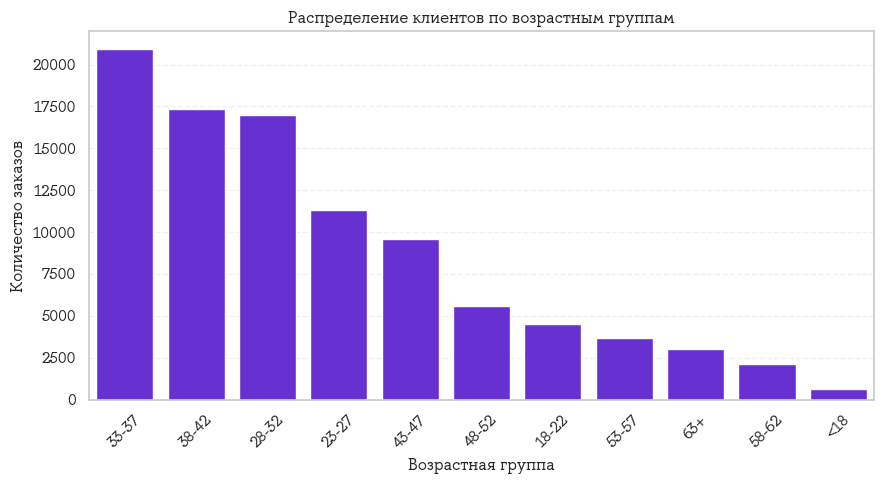

In [2]:
plt.figure(figsize=(9, 5))

order = (
    df['age_group']
    .dropna()
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    x="age_group",
    order=order
)

plt.title("Распределение клиентов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
import numpy as np

df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)


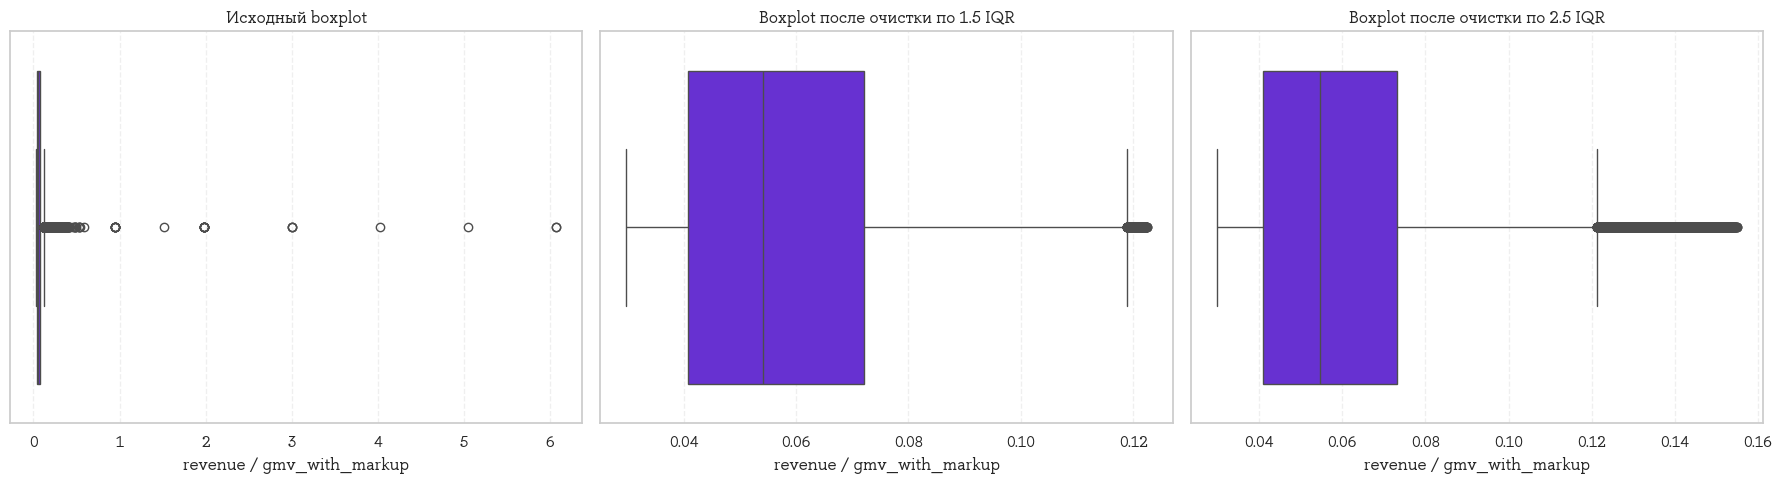

Исходно наблюдений: 89905
После очистки по 1.5 IQR: 87952
После очистки по 2.5 IQR: 89268


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

plot_data = (
    df["revenue_to_gmv_markup"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

def remove_outliers_iqr(series, multiplier):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return series[
        (series >= lower_bound) &
        (series <= upper_bound)
    ]

plot_data_1_5_iqr = remove_outliers_iqr(plot_data, multiplier=1.5)
plot_data_2_5_iqr = remove_outliers_iqr(plot_data, multiplier=2.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=plot_data, ax=axes[0])
axes[0].set_title("Исходный boxplot")
axes[0].set_xlabel("revenue / gmv_with_markup")

sns.boxplot(x=plot_data_1_5_iqr, ax=axes[1])
axes[1].set_title("Boxplot после очистки по 1.5 IQR")
axes[1].set_xlabel("revenue / gmv_with_markup")

sns.boxplot(x=plot_data_2_5_iqr, ax=axes[2])
axes[2].set_title("Boxplot после очистки по 2.5 IQR")
axes[2].set_xlabel("revenue / gmv_with_markup")

plt.tight_layout()
plt.show()

print(f"Исходно наблюдений: {len(plot_data)}")
print(f"После очистки по 1.5 IQR: {len(plot_data_1_5_iqr)}")
print(f"После очистки по 2.5 IQR: {len(plot_data_2_5_iqr)}")


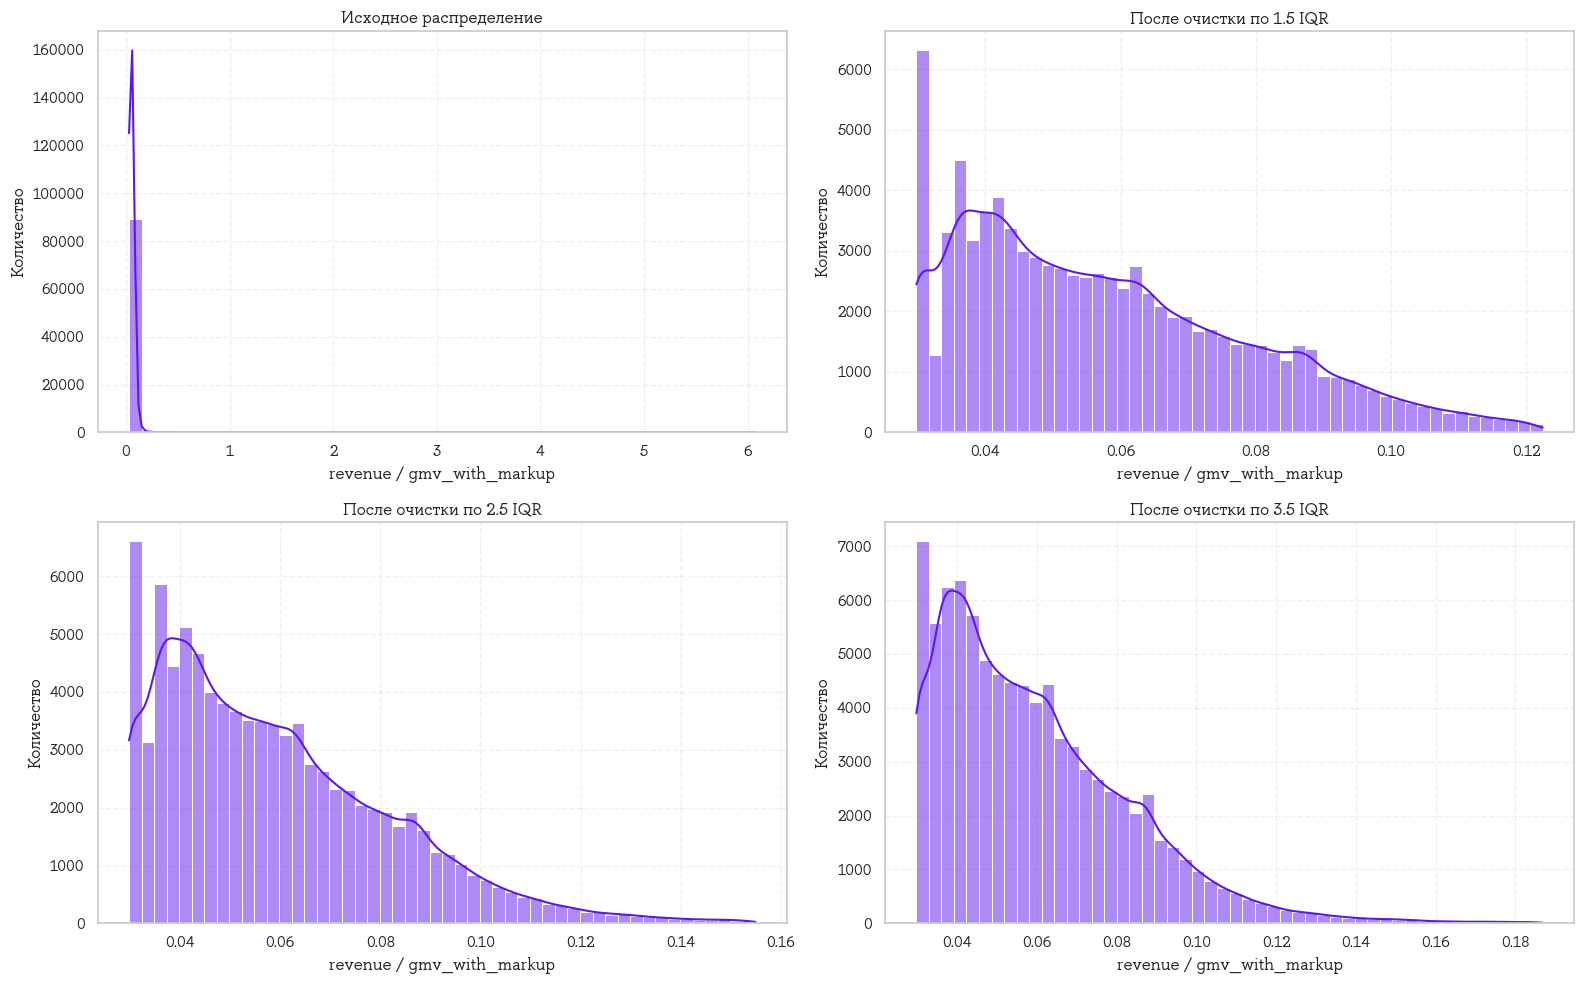

Исходно наблюдений: 89905
После очистки по 1.5 IQR: 87952
После очистки по 2.5 IQR: 89268
После очистки по 3.5 IQR: 89587


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

plot_data = (
    df["revenue_to_gmv_markup"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

def remove_outliers_iqr(series, multiplier):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return series[
        (series >= lower_bound) &
        (series <= upper_bound)
    ]

plot_data_1_5_iqr = remove_outliers_iqr(plot_data, multiplier=1.5)
plot_data_2_5_iqr = remove_outliers_iqr(plot_data, multiplier=2.5)
plot_data_3_5_iqr = remove_outliers_iqr(plot_data, multiplier=3.5)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(plot_data, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Исходное распределение")
axes[0, 0].set_xlabel("revenue / gmv_with_markup")
axes[0, 0].set_ylabel("Количество")

sns.histplot(plot_data_1_5_iqr, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("После очистки по 1.5 IQR")
axes[0, 1].set_xlabel("revenue / gmv_with_markup")
axes[0, 1].set_ylabel("Количество")

sns.histplot(plot_data_2_5_iqr, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("После очистки по 2.5 IQR")
axes[1, 0].set_xlabel("revenue / gmv_with_markup")
axes[1, 0].set_ylabel("Количество")

sns.histplot(plot_data_3_5_iqr, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("После очистки по 3.5 IQR")
axes[1, 1].set_xlabel("revenue / gmv_with_markup")
axes[1, 1].set_ylabel("Количество")

plt.tight_layout()
plt.show()

print(f"Исходно наблюдений: {len(plot_data)}")
print(f"После очистки по 1.5 IQR: {len(plot_data_1_5_iqr)}")
print(f"После очистки по 2.5 IQR: {len(plot_data_2_5_iqr)}")
print(f"После очистки по 3.5 IQR: {len(plot_data_3_5_iqr)}")


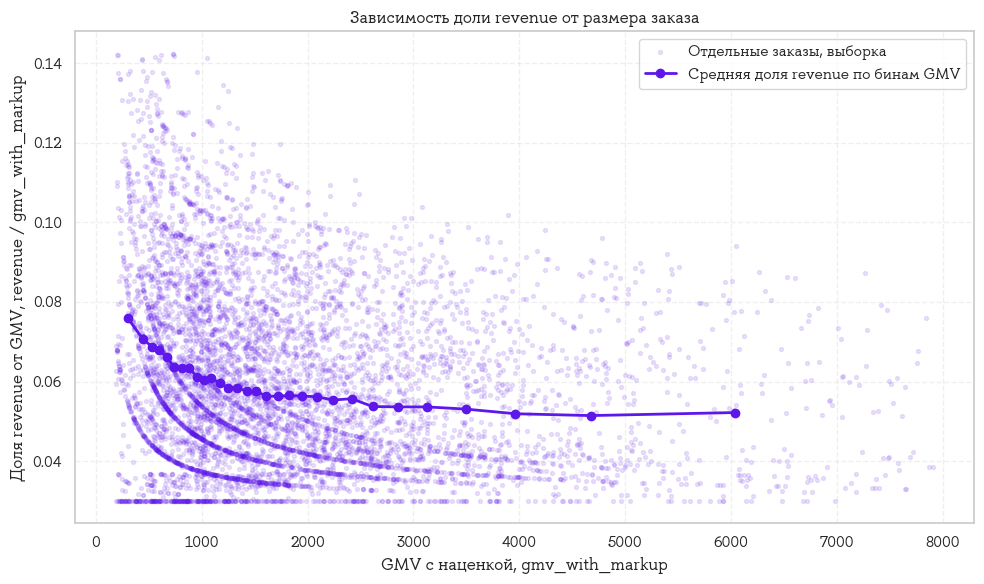

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot['revenue_share'] = df_plot['revenue'] / df_plot['gmv_with_markup']

df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=['gmv_with_markup', 'revenue_share'])
df_plot = df_plot[df_plot['gmv_with_markup'] > 0]

x_low, x_high = df_plot['gmv_with_markup'].quantile([0.01, 0.99])
y_low, y_high = df_plot['revenue_share'].quantile([0.01, 0.99])

df_vis = df_plot[
    df_plot['gmv_with_markup'].between(x_low, x_high) &
    df_plot['revenue_share'].between(y_low, y_high)
].copy()

df_vis['gmv_bin'] = pd.qcut(
    df_vis['gmv_with_markup'],
    q=30,
    duplicates='drop'
)

binned = (
    df_vis
    .groupby('gmv_bin', observed=True)
    .agg(
        gmv_mid=('gmv_with_markup', 'median'),
        revenue_share_mean=('revenue_share', 'mean'),
        revenue_share_median=('revenue_share', 'median'),
        n_orders=('revenue_share', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sample = df_vis.sample(min(7000, len(df_vis)), random_state=42)

plt.scatter(
    sample['gmv_with_markup'],
    sample['revenue_share'],
    alpha=0.12,
    s=8,
    label='Отдельные заказы, выборка'
)

plt.plot(
    binned['gmv_mid'],
    binned['revenue_share_mean'],
    marker='o',
    linewidth=2,
    label='Средняя доля revenue по бинам GMV'
)

plt.xlabel('GMV с наценкой, gmv_with_markup')
plt.ylabel('Доля revenue от GMV, revenue / gmv_with_markup')
plt.title('Зависимость доли revenue от размера заказа')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:          revenue_share   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1367.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:37:33   Log-Likelihood:             1.4039e+05
No. Observations:               89905   AIC:                        -2.808e+05
Df Residuals:                   89900   BIC:                        -2.807e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0606      0.000    144.978

,term,coef_pp,std_err_pp,z,p_value,ci_low_pp,ci_high_pp
0,Intercept,6.061164,0.041807,144.978148,0.000000e+00,5.979223,6.143105
1,cb_percent,-0.101738,0.003985,-25.528252,9.576534e-144,-0.109549,-0.093927
2,cb_x_markup_1,0.021779,0.004028,5.406895,6.412667e-08,0.013884,0.029673
3,cb_x_markup_5,0.153891,0.004992,30.829057,1.069314e-208,0.144107,0.163675
4,cb_x_markup_9,0.271870,0.004123,65.943266,0.000000e+00,0.263789,0.279950


<Wald test (chi2): statistic=[[5438.95787416]], p-value=0.0, df_denom=3>


,cb_percent,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9
cb_percent,1.000000,0.300662,0.303325,0.293226
cb_x_markup_1,0.300662,1.000000,-0.196960,-0.194302
cb_x_markup_5,0.303325,-0.196960,1.000000,-0.191421
cb_x_markup_9,0.293226,-0.194302,-0.191421,1.000000


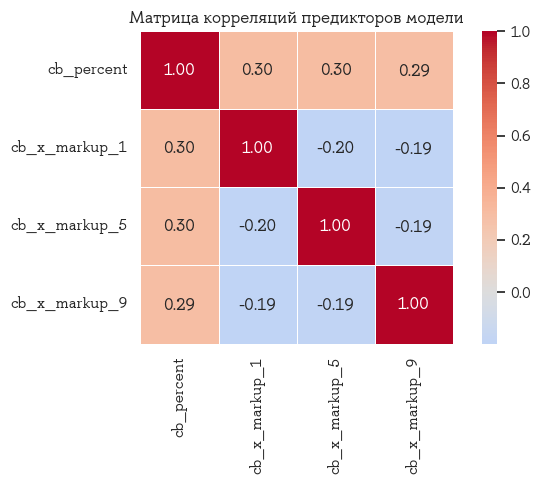

,variable,VIF
1,cb_percent,1.782024
3,cb_x_markup_5,1.535707
2,cb_x_markup_1,1.535119
4,cb_x_markup_9,1.517872


,cb_percent,markup,markup_1,markup_5,markup_9,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9,predicted_revenue_share,ci_low,ci_high,predicted_revenue_share_pp,ci_low_pp,ci_high_pp
0,0.000000,0,0,0,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
1,0.000000,1,1,0,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
2,0.000000,5,0,1,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
3,0.000000,9,0,0,1,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
4,0.252525,0,0,0,0,0.0,0.0,0.000000,0.060355,0.059549,0.061160,6.035473,5.954924,6.116022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,24.747475,9,0,0,1,0.0,0.0,24.747475,0.102715,0.101090,0.104340,10.271501,10.108953,10.434049
396,25.000000,0,0,0,0,0.0,0.0,0.000000,0.035177,0.033692,0.036663,3.517721,3.369176,3.666265
397,25.000000,1,1,0,0,25.0,0.0,0.000000,0.040622,0.039021,0.042223,4.062190,3.902119,4.222260
398,25.000000,5,0,1,0,0.0,25.0,0.000000,0.073650,0.071421,0.075879,7.364996,7.142093,7.587898


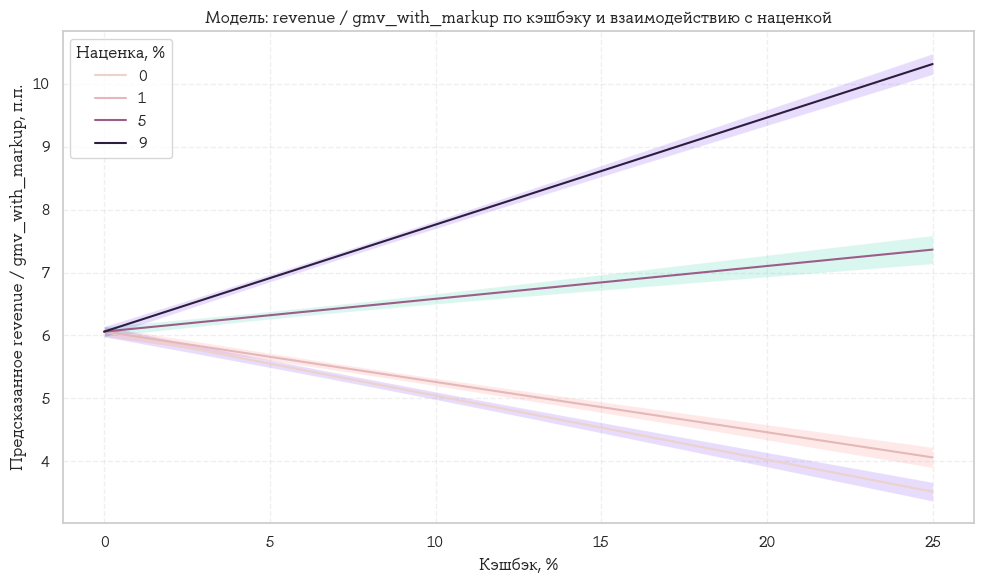

AttributeError: 'numpy.ndarray' object has no attribute 'nunique'

In [ ]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model['revenue_share'] = df_model['revenue'] / df_model['gmv_with_markup']

df_model = df_model.dropna(
    subset=[
        'revenue_share',
        'markup',
        'cb_percent'
    ]
).copy()

df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()
df_model['markup'] = df_model['markup'].astype(int)

df_model['markup_1'] = (df_model['markup'] == 1).astype(int)
df_model['markup_5'] = (df_model['markup'] == 5).astype(int)
df_model['markup_9'] = (df_model['markup'] == 9).astype(int)

df_model['cb_x_markup_1'] = df_model['cb_percent'] * df_model['markup_1']
df_model['cb_x_markup_5'] = df_model['cb_percent'] * df_model['markup_5']
df_model['cb_x_markup_9'] = df_model['cb_percent'] * df_model['markup_9']

formula = """
revenue_share ~ cb_percent
              + cb_x_markup_1
              + cb_x_markup_5
              + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_cb_only.summary())

coef_table_cb_only = model_cb_only.summary2().tables[1].reset_index()
coef_table_cb_only = coef_table_cb_only.rename(columns={'index': 'term'})

for col in ['Coef.', 'Std.Err.', '[0.025', '0.975]']:
    coef_table_cb_only[col] = coef_table_cb_only[col] * 100

coef_table_cb_only = coef_table_cb_only.rename(columns={
    'Coef.': 'coef_pp',
    'Std.Err.': 'std_err_pp',
    '[0.025': 'ci_low_pp',
    '0.975]': 'ci_high_pp',
    'P>|z|': 'p_value'
})

display(coef_table_cb_only)

print(
    model_cb_only.wald_test(
        'cb_x_markup_1 = 0, cb_x_markup_5 = 0, cb_x_markup_9 = 0'
    )
)

predictors_cb_only = [
    'cb_percent',
    'cb_x_markup_1',
    'cb_x_markup_5',
    'cb_x_markup_9'
]

X_cb_only = df_model[predictors_cb_only].dropna().copy()

corr_matrix_cb_only = X_cb_only.corr()

display(corr_matrix_cb_only)

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix_cb_only,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций предикторов модели')
plt.tight_layout()
plt.show()

X_vif_cb_only = sm.add_constant(X_cb_only)

vif_table_cb_only = pd.DataFrame({
    'variable': X_vif_cb_only.columns,
    'VIF': [
        variance_inflation_factor(X_vif_cb_only.values, i)
        for i in range(X_vif_cb_only.shape[1])
    ]
})

vif_table_cb_only = vif_table_cb_only[vif_table_cb_only['variable'] != 'const'].copy()
vif_table_cb_only = vif_table_cb_only.sort_values('VIF', ascending=False)

display(vif_table_cb_only)

cb_min = df_model['cb_percent'].quantile(0.01)
cb_max = df_model['cb_percent'].quantile(0.99)

cb_grid = np.linspace(cb_min, cb_max, 100)

pred_grid = pd.DataFrame([
    {
        'cb_percent': cb,
        'markup': markup
    }
    for cb in cb_grid
    for markup in [0, 1, 5, 9]
])

pred_grid['markup_1'] = (pred_grid['markup'] == 1).astype(int)
pred_grid['markup_5'] = (pred_grid['markup'] == 5).astype(int)
pred_grid['markup_9'] = (pred_grid['markup'] == 9).astype(int)

pred_grid['cb_x_markup_1'] = pred_grid['cb_percent'] * pred_grid['markup_1']
pred_grid['cb_x_markup_5'] = pred_grid['cb_percent'] * pred_grid['markup_5']
pred_grid['cb_x_markup_9'] = pred_grid['cb_percent'] * pred_grid['markup_9']

pred = model_cb_only.get_prediction(pred_grid).summary_frame(alpha=0.05)

pred_grid['predicted_revenue_share'] = pred['mean']
pred_grid['ci_low'] = pred['mean_ci_lower']
pred_grid['ci_high'] = pred['mean_ci_upper']

pred_grid['predicted_revenue_share_pp'] = pred_grid['predicted_revenue_share'] * 100
pred_grid['ci_low_pp'] = pred_grid['ci_low'] * 100
pred_grid['ci_high_pp'] = pred_grid['ci_high'] * 100

display(pred_grid)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pred_grid,
    x='cb_percent',
    y='predicted_revenue_share_pp',
    hue='markup'
)

for markup_value in [0, 1, 5, 9]:
    temp = pred_grid[pred_grid['markup'] == markup_value]

    plt.fill_between(
        temp['cb_percent'],
        temp['ci_low_pp'],
        temp['ci_high_pp'],
        alpha=0.15
    )

plt.title('Модель: revenue / gmv_with_markup по кэшбэку и взаимодействию с наценкой')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Предсказанное revenue / gmv_with_markup, п.п.')
plt.legend(title='Наценка, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


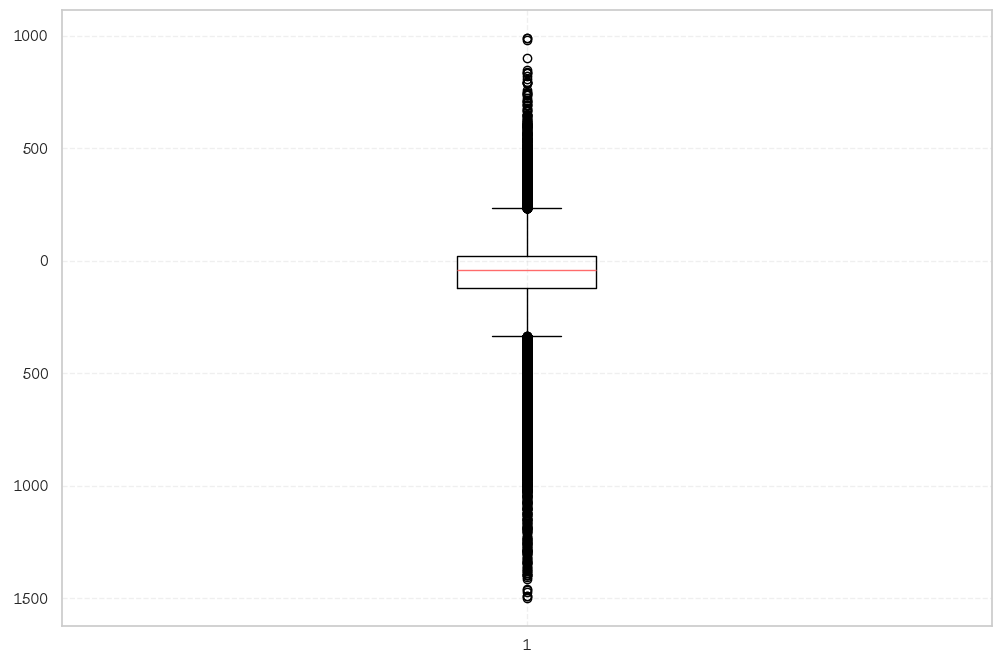

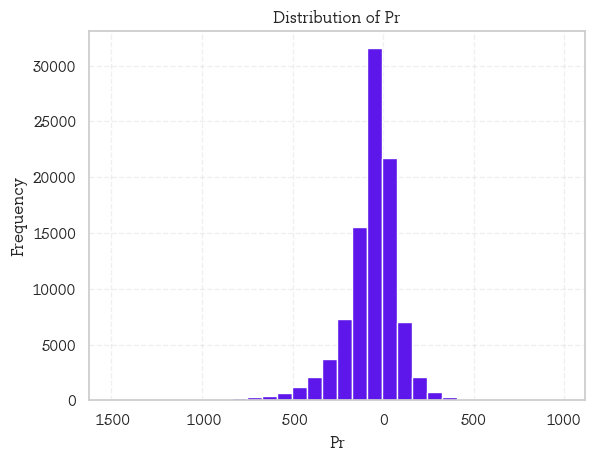

In [3]:
df['Pr'] = df['revenue'] - df['gmv_with_markup']*df['cb_percent']/100

df = df[(df['Pr'] < 1000) & (df['Pr'] > -1500)]

plt.figure(figsize = (12,8))
plt.boxplot(df['Pr'])
plt.show()

plt.figure()

plt.hist(df['Pr'].dropna(), bins=30)

plt.xlabel('Pr')
plt.ylabel('Frequency')
plt.title('Distribution of Pr')

plt.show()

                            OLS Regression Results                            
Dep. Variable:                     Pr   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     7692.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:17:37   Log-Likelihood:            -5.9029e+05
No. Observations:               95670   AIC:                         1.181e+06
Df Residuals:                   95664   BIC:                         1.181e+06
Df Model:                           5                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       103.7121      0.948    109.434

,term,coef,std_err,z,p_value,ci_low,ci_high
0,Intercept,103.712141,0.947715,109.433885,0.000000e+00,101.854654,105.569629
1,cb_percent,-21.037587,0.286882,-73.331829,0.000000e+00,-21.599866,-20.475309
2,cb_percent_sq,0.055833,0.016893,3.305010,9.497289e-04,0.022722,0.088943
3,cb_x_markup_1,-0.313302,0.181644,-1.724810,8.456178e-02,-0.669318,0.042714
4,cb_x_markup_5,2.493323,0.175624,14.196899,9.575718e-46,2.149105,2.837540
5,cb_x_markup_9,4.778976,0.164757,29.006129,5.506862e-185,4.456058,5.101895


Совместный тест взаимодействий cb_percent × markup:
<Wald test (chi2): statistic=[[1295.99872099]], p-value=1.0865019874249568e-280, df_denom=3>
Тест квадратичного эффекта cb_percent:
<Wald test (chi2): statistic=[[10.92309353]], p-value=0.0009497288692206068, df_denom=1>


,cb_percent,cb_percent_sq,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9
cb_percent,1.000000,0.930797,0.300113,0.302309,0.293099
cb_percent_sq,0.930797,1.000000,0.277278,0.283197,0.271521
cb_x_markup_1,0.300113,0.277278,1.000000,-0.198713,-0.195981
cb_x_markup_5,0.302309,0.283197,-0.198713,1.000000,-0.192814
cb_x_markup_9,0.293099,0.271521,-0.195981,-0.192814,1.000000


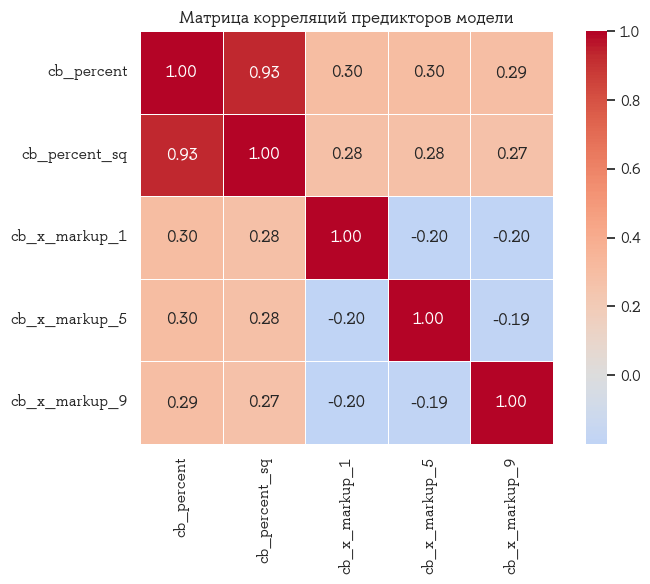

,variable,VIF
1,cb_percent,8.287383
2,cb_percent_sq,7.484612
3,cb_x_markup_1,1.541012
4,cb_x_markup_5,1.540510
5,cb_x_markup_9,1.523846


,cb_percent,markup,cb_percent_sq,markup_1,markup_5,markup_9,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9,predicted_Pr,ci_low,ci_high
0,0.000000,0,0.000000,0,0,0,0.0,0.0,0.000000,103.712141,101.854654,105.569629
1,0.000000,1,0.000000,1,0,0,0.0,0.0,0.000000,103.712141,101.854654,105.569629
2,0.000000,5,0.000000,0,1,0,0.0,0.0,0.000000,103.712141,101.854654,105.569629
3,0.000000,9,0.000000,0,0,1,0.0,0.0,0.000000,103.712141,101.854654,105.569629
4,0.252525,0,0.063769,0,0,0,0.0,0.0,0.000000,98.403180,96.639889,100.166471
...,...,...,...,...,...,...,...,...,...,...,...,...
395,24.747475,9,612.437506,0,0,1,0.0,0.0,24.747475,-264.453456,-274.458336,-254.448577
396,25.000000,0,625.000000,0,0,0,0.0,0.0,0.000000,-387.332180,-398.816093,-375.848268
397,25.000000,1,625.000000,1,0,0,25.0,0.0,0.000000,-395.164723,-406.193808,-384.135638
398,25.000000,5,625.000000,0,1,0,0.0,25.0,0.000000,-324.999109,-335.816063,-314.182156


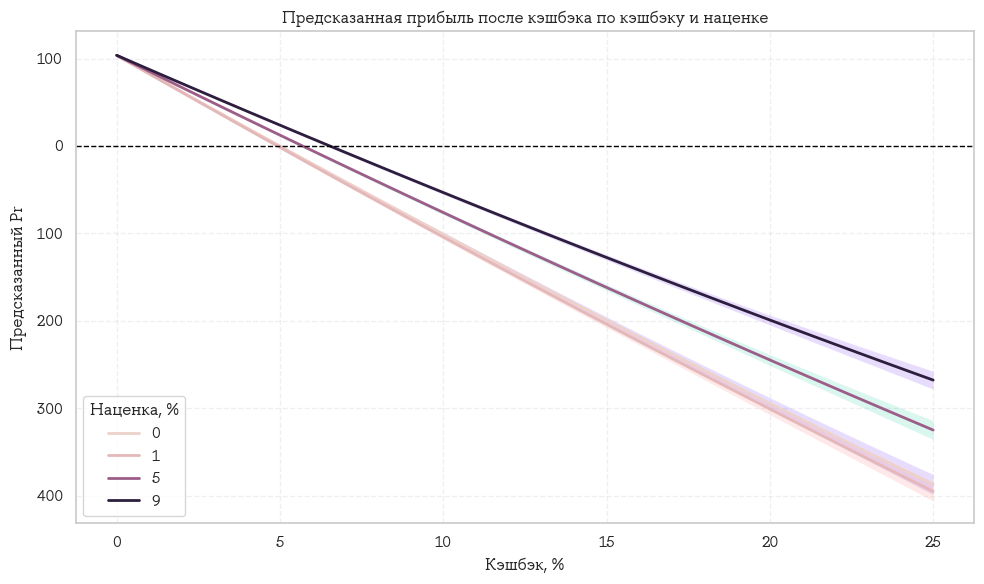

,markup,cb_percent,Pr_mean,n_orders
0,0,0,67.281916,6099
1,0,5,-16.987746,1394
2,0,7,-56.636948,5172
3,0,10,-103.658663,2690
4,0,12,-137.790159,5699
5,0,15,-198.456560,2600
6,0,17,-241.499111,2847
7,0,18,-252.129514,117
8,0,20,-253.185707,167
9,0,23,-291.562571,253


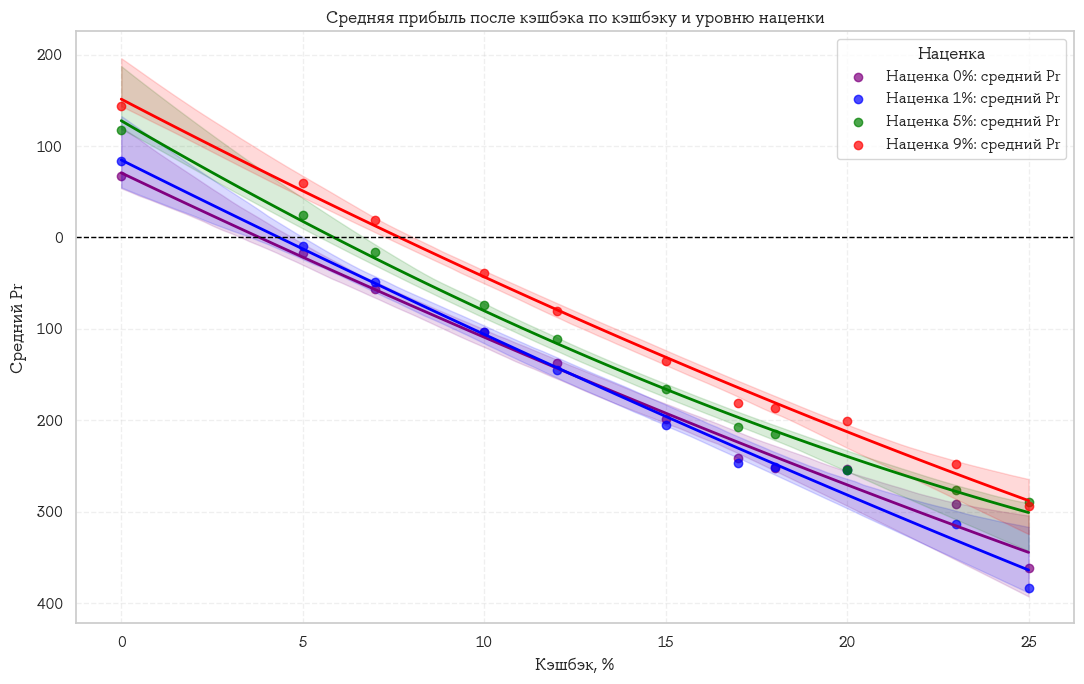

In [4]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Оставляем только заказы с положительным GMV
df_model = df_model[df_model['gmv_with_markup'] > 0].copy()

# Создаем метрику прибыли после кэшбэка
df_model['Pr'] = (
    df_model['revenue']
    - df_model['gmv_with_markup'] * df_model['cb_percent'] / 100
)

# Оставляем только нужные наблюдения
df_model = df_model.dropna(
    subset=[
        'Pr',
        'revenue',
        'gmv_with_markup',
        'markup',
        'cb_percent'
    ]
).copy()

# Оставляем только нужные уровни наценки
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()
df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Флаги наценки
# =========================
# Базовая группа: markup = 0
# Сами флаги отдельно в модель не включаем

df_model['markup_1'] = (df_model['markup'] == 1).astype(int)
df_model['markup_5'] = (df_model['markup'] == 5).astype(int)
df_model['markup_9'] = (df_model['markup'] == 9).astype(int)

# =========================
# 3. cb_percent, квадрат и взаимодействия
# =========================

df_model['cb_percent_sq'] = df_model['cb_percent'] ** 2

df_model['cb_x_markup_1'] = df_model['cb_percent'] * df_model['markup_1']
df_model['cb_x_markup_5'] = df_model['cb_percent'] * df_model['markup_5']
df_model['cb_x_markup_9'] = df_model['cb_percent'] * df_model['markup_9']

# =========================
# 4. Линейная регрессия
# =========================

formula = """
Pr ~ cb_percent
   + cb_percent_sq
   + cb_x_markup_1
   + cb_x_markup_5
   + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_pr_cb_sq = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_pr_cb_sq = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_pr_cb_sq.summary())

# =========================
# 5. Таблица коэффициентов
# =========================

coef_table = model_pr_cb_sq.summary2().tables[1].reset_index()

coef_table = coef_table.rename(columns={
    'index': 'term',
    'Coef.': 'coef',
    'Std.Err.': 'std_err',
    '[0.025': 'ci_low',
    '0.975]': 'ci_high'
})

# Универсальное переименование p-value
if 'P>|z|' in coef_table.columns:
    coef_table = coef_table.rename(columns={'P>|z|': 'p_value'})
elif 'P>|t|' in coef_table.columns:
    coef_table = coef_table.rename(columns={'P>|t|': 'p_value'})

display(coef_table)

# =========================
# 6. Совместные тесты
# =========================

print('Совместный тест взаимодействий cb_percent × markup:')
print(
    model_pr_cb_sq.wald_test(
        'cb_x_markup_1 = 0, cb_x_markup_5 = 0, cb_x_markup_9 = 0'
    )
)

print('Тест квадратичного эффекта cb_percent:')
print(
    model_pr_cb_sq.wald_test(
        'cb_percent_sq = 0'
    )
)

# =========================
# 7. Матрица корреляций предикторов
# =========================

predictors = [
    'cb_percent',
    'cb_percent_sq',
    'cb_x_markup_1',
    'cb_x_markup_5',
    'cb_x_markup_9'
]

X = df_model[predictors].dropna().copy()

corr_matrix = X.corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций предикторов модели')
plt.tight_layout()
plt.show()

# =========================
# 8. VIF
# =========================

X_vif = sm.add_constant(X)

vif_table = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table[vif_table['variable'] != 'const'].copy()
vif_table = vif_table.sort_values('VIF', ascending=False)

display(vif_table)

# =========================
# 9. Предсказания модели
# =========================

cb_min = df_model['cb_percent'].quantile(0.01)
cb_max = df_model['cb_percent'].quantile(0.99)

cb_grid = np.linspace(cb_min, cb_max, 100)

pred_grid = pd.DataFrame([
    {
        'cb_percent': cb,
        'markup': markup
    }
    for cb in cb_grid
    for markup in [0, 1, 5, 9]
])

pred_grid['cb_percent_sq'] = pred_grid['cb_percent'] ** 2

pred_grid['markup_1'] = (pred_grid['markup'] == 1).astype(int)
pred_grid['markup_5'] = (pred_grid['markup'] == 5).astype(int)
pred_grid['markup_9'] = (pred_grid['markup'] == 9).astype(int)

pred_grid['cb_x_markup_1'] = pred_grid['cb_percent'] * pred_grid['markup_1']
pred_grid['cb_x_markup_5'] = pred_grid['cb_percent'] * pred_grid['markup_5']
pred_grid['cb_x_markup_9'] = pred_grid['cb_percent'] * pred_grid['markup_9']

pred = model_pr_cb_sq.get_prediction(pred_grid).summary_frame(alpha=0.05)

pred_grid['predicted_Pr'] = pred['mean']
pred_grid['ci_low'] = pred['mean_ci_lower']
pred_grid['ci_high'] = pred['mean_ci_upper']

display(pred_grid)

# =========================
# 10. График предсказаний модели
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pred_grid,
    x='cb_percent',
    y='predicted_Pr',
    hue='markup',
    linewidth=2
)

for markup_value in [0, 1, 5, 9]:
    temp = pred_grid[pred_grid['markup'] == markup_value].copy()

    plt.fill_between(
        temp['cb_percent'].to_numpy(),
        temp['ci_low'].to_numpy(),
        temp['ci_high'].to_numpy(),
        alpha=0.15
    )

plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title('Предсказанная прибыль после кэшбэка по кэшбэку и наценке')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Предсказанный Pr')
plt.legend(title='Наценка, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 11. Описательный bootstrap-график средних Pr
# =========================

plot_data = df_model[
    [
        'markup',
        'cb_percent',
        'Pr'
    ]
].dropna().copy()

cb_markup_avg = (
    plot_data
    .groupby(['markup', 'cb_percent'], as_index=False)
    .agg(
        Pr_mean=('Pr', 'mean'),
        n_orders=('Pr', 'size')
    )
)

display(cb_markup_avg)

def bootstrap_poly_fit(x, y, x_fit, degree=2, n_bootstraps=1000, confidence=0.95):
    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    bootstrap_fits = np.zeros((n_bootstraps, len(x_fit)))

    for i in range(n_bootstraps):
        indices = np.random.choice(n, n, replace=True)

        x_resample = x[indices]
        y_resample = y[indices]

        if len(np.unique(x_resample)) <= degree:
            bootstrap_fits[i, :] = np.nan
            continue

        coefficients_resample = np.polyfit(x_resample, y_resample, degree)
        polynomial_resample = np.poly1d(coefficients_resample)

        bootstrap_fits[i, :] = polynomial_resample(x_fit)

    lower_percentile = (1 - confidence) / 2 * 100
    upper_percentile = (1 + confidence) / 2 * 100

    lower_bound = np.nanpercentile(bootstrap_fits, lower_percentile, axis=0)
    upper_bound = np.nanpercentile(bootstrap_fits, upper_percentile, axis=0)

    return lower_bound, upper_bound

plt.figure(figsize=(11, 7))

palette = {
    0: 'purple',
    1: 'blue',
    5: 'green',
    9: 'red'
}

degree = 2

for markup_value in [0, 1, 5, 9]:
    temp = cb_markup_avg[cb_markup_avg['markup'] == markup_value].copy()

    if temp['cb_percent'].nunique() <= degree:
        print(f"Для markup={markup_value}% слишком мало уникальных значений cb_percent")
        continue

    x_data = temp['cb_percent'].values
    y_data = temp['Pr_mean'].values

    plt.scatter(
        x_data,
        y_data,
        color=palette[markup_value],
        alpha=0.7,
        label=f'Наценка {markup_value}%: средний Pr'
    )

    coefficients = np.polyfit(x_data, y_data, degree)
    polynomial = np.poly1d(coefficients)

    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit = polynomial(x_fit)

    plt.plot(
        x_fit,
        y_fit,
        color=palette[markup_value],
        linewidth=2
    )

    lower_bound, upper_bound = bootstrap_poly_fit(
        x=x_data,
        y=y_data,
        x_fit=x_fit,
        degree=degree,
        n_bootstraps=1000,
        confidence=0.95
    )

    plt.fill_between(
        x_fit,
        lower_bound,
        upper_bound,
        color=palette[markup_value],
        alpha=0.15
    )

plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title("Средняя прибыль после кэшбэка по кэшбэку и уровню наценки")
plt.xlabel("Кэшбэк, %")
plt.ylabel("Средний Pr")
plt.legend(title='Наценка')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                     Pr   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     7584.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:19:43   Log-Likelihood:            -5.9031e+05
No. Observations:               95670   AIC:                         1.181e+06
Df Residuals:                   95665   BIC:                         1.181e+06
Df Model:                           4                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       101.2587      0.849    119.323

,term,coef,std_err,z,p_value,ci_low,ci_high
0,Intercept,101.258738,0.848614,119.322546,0.000000e+00,99.595486,102.921990
1,cb_percent,-20.030561,0.157234,-127.393197,0.000000e+00,-20.338734,-19.722387
2,cb_x_markup_1,-0.317080,0.182254,-1.739769,8.189959e-02,-0.674291,0.040131
3,cb_x_markup_5,2.493902,0.176275,14.147789,1.927212e-45,2.148410,2.839395
4,cb_x_markup_9,4.776021,0.165177,28.914644,7.814706e-184,4.452281,5.099761


Совместный тест взаимодействий cb_percent × markup:
<Wald test (chi2): statistic=[[1292.96833752]], p-value=4.938128373338516e-280, df_denom=3>


,cb_percent,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9
cb_percent,1.000000,0.300113,0.302309,0.293099
cb_x_markup_1,0.300113,1.000000,-0.198713,-0.195981
cb_x_markup_5,0.302309,-0.198713,1.000000,-0.192814
cb_x_markup_9,0.293099,-0.195981,-0.192814,1.000000


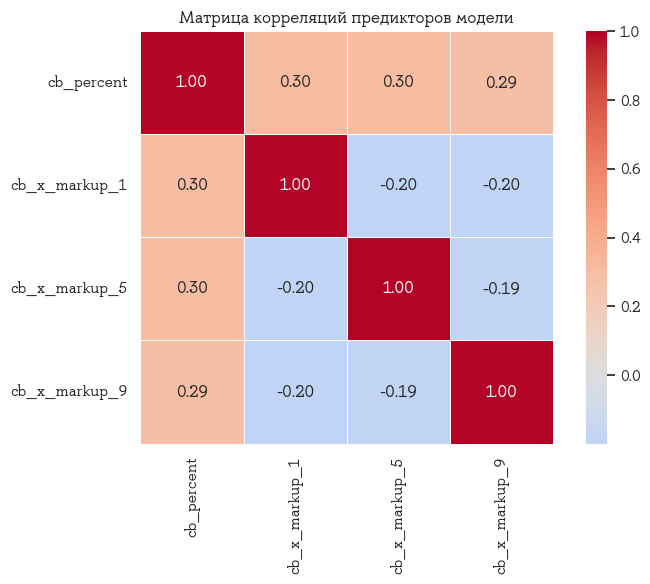

,variable,VIF
1,cb_percent,1.784095
2,cb_x_markup_1,1.540953
3,cb_x_markup_5,1.540509
4,cb_x_markup_9,1.523811


,cb_percent,markup,markup_1,markup_5,markup_9,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9,predicted_Pr,ci_low,ci_high
0,0.000000,0,0,0,0,0.0,0.0,0.000000,101.258738,99.595486,102.921990
1,0.000000,1,1,0,0,0.0,0.0,0.000000,101.258738,99.595486,102.921990
2,0.000000,5,0,1,0,0.0,0.0,0.000000,101.258738,99.595486,102.921990
3,0.000000,9,0,0,1,0.0,0.0,0.000000,101.258738,99.595486,102.921990
4,0.252525,0,0,0,0,0.0,0.0,0.000000,96.200516,94.583487,97.817545
...,...,...,...,...,...,...,...,...,...,...,...
395,24.747475,9,0,0,1,0.0,0.0,24.747475,-276.252592,-281.753209,-270.751975
396,25.000000,0,0,0,0,0.0,0.0,0.000000,-399.505276,-406.325299,-392.685254
397,25.000000,1,1,0,0,25.0,0.0,0.000000,-407.432272,-414.207579,-400.656964
398,25.000000,5,0,1,0,0.0,25.0,0.000000,-337.157718,-343.569468,-330.745968


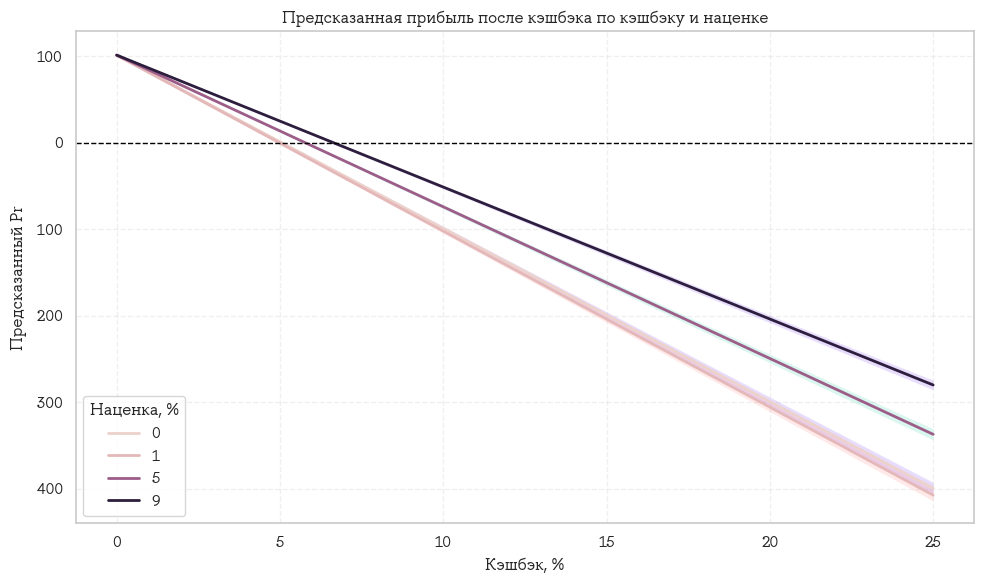

,markup,cb_percent,Pr_mean,n_orders
0,0,0,67.281916,6099
1,0,5,-16.987746,1394
2,0,7,-56.636948,5172
3,0,10,-103.658663,2690
4,0,12,-137.790159,5699
5,0,15,-198.456560,2600
6,0,17,-241.499111,2847
7,0,18,-252.129514,117
8,0,20,-253.185707,167
9,0,23,-291.562571,253


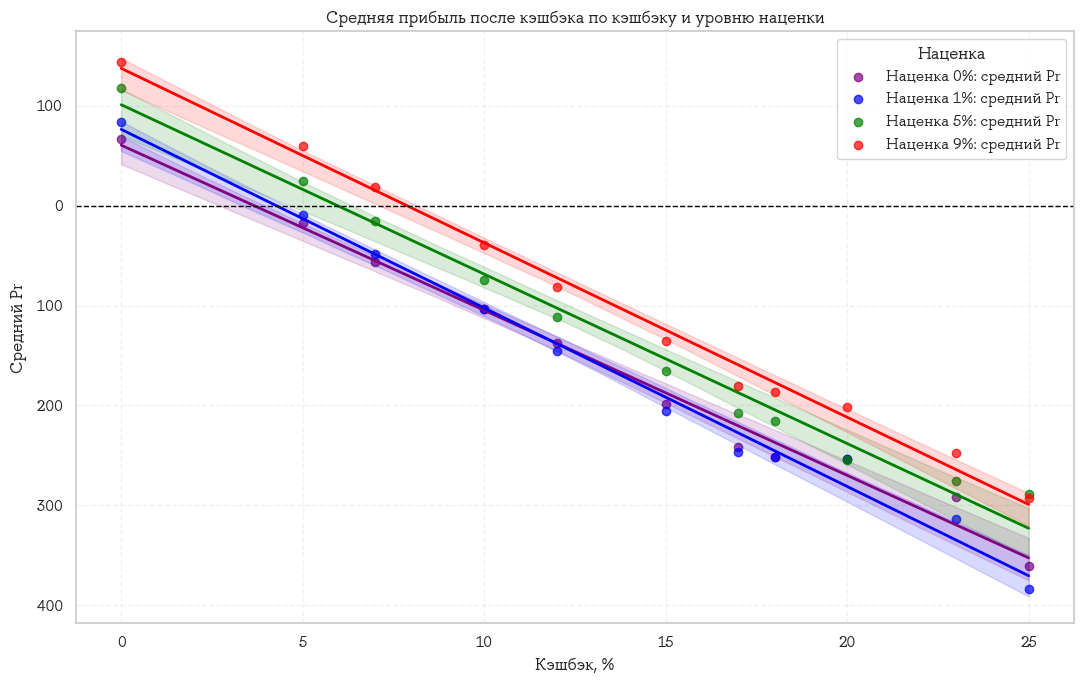

In [5]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()

df_model['Pr'] = (
    df_model['revenue']
    - df_model['gmv_with_markup'] * df_model['cb_percent'] / 100
)

df_model = df_model.dropna(
    subset=[
        'Pr',
        'revenue',
        'gmv_with_markup',
        'markup',
        'cb_percent'
    ]
).copy()

df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()
df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Флаги наценки
# =========================
# Базовая группа: markup = 0
# Сами флаги отдельно в модель не включаем

df_model['markup_1'] = (df_model['markup'] == 1).astype(int)
df_model['markup_5'] = (df_model['markup'] == 5).astype(int)
df_model['markup_9'] = (df_model['markup'] == 9).astype(int)

# =========================
# 3. Взаимодействия cb_percent × markup
# =========================

df_model['cb_x_markup_1'] = df_model['cb_percent'] * df_model['markup_1']
df_model['cb_x_markup_5'] = df_model['cb_percent'] * df_model['markup_5']
df_model['cb_x_markup_9'] = df_model['cb_percent'] * df_model['markup_9']

# =========================
# 4. Линейная регрессия
# =========================

formula = """
Pr ~ cb_percent
   + cb_x_markup_1
   + cb_x_markup_5
   + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_pr_cb = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_pr_cb = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_pr_cb.summary())

# =========================
# 5. Таблица коэффициентов
# =========================

coef_table = model_pr_cb.summary2().tables[1].reset_index()

coef_table = coef_table.rename(columns={
    'index': 'term',
    'Coef.': 'coef',
    'Std.Err.': 'std_err',
    '[0.025': 'ci_low',
    '0.975]': 'ci_high'
})

if 'P>|z|' in coef_table.columns:
    coef_table = coef_table.rename(columns={'P>|z|': 'p_value'})
elif 'P>|t|' in coef_table.columns:
    coef_table = coef_table.rename(columns={'P>|t|': 'p_value'})

display(coef_table)

# =========================
# 6. Совместный тест взаимодействий
# =========================

print('Совместный тест взаимодействий cb_percent × markup:')
print(
    model_pr_cb.wald_test(
        'cb_x_markup_1 = 0, cb_x_markup_5 = 0, cb_x_markup_9 = 0'
    )
)

# =========================
# 7. Матрица корреляций предикторов
# =========================

predictors = [
    'cb_percent',
    'cb_x_markup_1',
    'cb_x_markup_5',
    'cb_x_markup_9'
]

X = df_model[predictors].dropna().copy()

corr_matrix = X.corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций предикторов модели')
plt.tight_layout()
plt.show()

# =========================
# 8. VIF
# =========================

X_vif = sm.add_constant(X)

vif_table = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table[vif_table['variable'] != 'const'].copy()
vif_table = vif_table.sort_values('VIF', ascending=False)

display(vif_table)

# =========================
# 9. Предсказания модели
# =========================

cb_min = df_model['cb_percent'].quantile(0.01)
cb_max = df_model['cb_percent'].quantile(0.99)

cb_grid = np.linspace(cb_min, cb_max, 100)

pred_grid = pd.DataFrame([
    {
        'cb_percent': cb,
        'markup': markup
    }
    for cb in cb_grid
    for markup in [0, 1, 5, 9]
])

pred_grid['markup_1'] = (pred_grid['markup'] == 1).astype(int)
pred_grid['markup_5'] = (pred_grid['markup'] == 5).astype(int)
pred_grid['markup_9'] = (pred_grid['markup'] == 9).astype(int)

pred_grid['cb_x_markup_1'] = pred_grid['cb_percent'] * pred_grid['markup_1']
pred_grid['cb_x_markup_5'] = pred_grid['cb_percent'] * pred_grid['markup_5']
pred_grid['cb_x_markup_9'] = pred_grid['cb_percent'] * pred_grid['markup_9']

pred = model_pr_cb.get_prediction(pred_grid).summary_frame(alpha=0.05)

pred_grid['predicted_Pr'] = pred['mean']
pred_grid['ci_low'] = pred['mean_ci_lower']
pred_grid['ci_high'] = pred['mean_ci_upper']

display(pred_grid)

# =========================
# 10. График предсказаний модели
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pred_grid,
    x='cb_percent',
    y='predicted_Pr',
    hue='markup',
    linewidth=2
)

for markup_value in [0, 1, 5, 9]:
    temp = pred_grid[pred_grid['markup'] == markup_value].copy()

    plt.fill_between(
        temp['cb_percent'].to_numpy(),
        temp['ci_low'].to_numpy(),
        temp['ci_high'].to_numpy(),
        alpha=0.15
    )

plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title('Предсказанная прибыль после кэшбэка по кэшбэку и наценке')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Предсказанный Pr')
plt.legend(title='Наценка, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 11. Описательный bootstrap-график средних Pr
# =========================

plot_data = df_model[
    [
        'markup',
        'cb_percent',
        'Pr'
    ]
].dropna().copy()

cb_markup_avg = (
    plot_data
    .groupby(['markup', 'cb_percent'], as_index=False)
    .agg(
        Pr_mean=('Pr', 'mean'),
        n_orders=('Pr', 'size')
    )
)

display(cb_markup_avg)

def bootstrap_linear_fit(x, y, x_fit, n_bootstraps=1000, confidence=0.95):
    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    bootstrap_fits = np.zeros((n_bootstraps, len(x_fit)))

    for i in range(n_bootstraps):
        indices = np.random.choice(n, n, replace=True)

        x_resample = x[indices]
        y_resample = y[indices]

        if len(np.unique(x_resample)) <= 1:
            bootstrap_fits[i, :] = np.nan
            continue

        coefficients_resample = np.polyfit(x_resample, y_resample, 1)
        polynomial_resample = np.poly1d(coefficients_resample)

        bootstrap_fits[i, :] = polynomial_resample(x_fit)

    lower_percentile = (1 - confidence) / 2 * 100
    upper_percentile = (1 + confidence) / 2 * 100

    lower_bound = np.nanpercentile(bootstrap_fits, lower_percentile, axis=0)
    upper_bound = np.nanpercentile(bootstrap_fits, upper_percentile, axis=0)

    return lower_bound, upper_bound

plt.figure(figsize=(11, 7))

palette = {
    0: 'purple',
    1: 'blue',
    5: 'green',
    9: 'red'
}

for markup_value in [0, 1, 5, 9]:
    temp = cb_markup_avg[cb_markup_avg['markup'] == markup_value].copy()

    if temp['cb_percent'].nunique() <= 1:
        print(f"Для markup={markup_value}% слишком мало уникальных значений cb_percent")
        continue

    x_data = temp['cb_percent'].values
    y_data = temp['Pr_mean'].values

    plt.scatter(
        x_data,
        y_data,
        color=palette[markup_value],
        alpha=0.7,
        label=f'Наценка {markup_value}%: средний Pr'
    )

    coefficients = np.polyfit(x_data, y_data, 1)
    polynomial = np.poly1d(coefficients)

    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit = polynomial(x_fit)

    plt.plot(
        x_fit,
        y_fit,
        color=palette[markup_value],
        linewidth=2
    )

    lower_bound, upper_bound = bootstrap_linear_fit(
        x=x_data,
        y=y_data,
        x_fit=x_fit,
        n_bootstraps=1000,
        confidence=0.95
    )

    plt.fill_between(
        x_fit,
        lower_bound,
        upper_bound,
        color=palette[markup_value],
        alpha=0.15
    )

plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title("Средняя прибыль после кэшбэка по кэшбэку и уровню наценки")
plt.xlabel("Кэшбэк, %")
plt.ylabel("Средний Pr")
plt.legend(title='Наценка')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# =========================
# 4. Линейная регрессия
# =========================

formula = """
Pr ~ cb_percent
   + markup_1
   + markup_5
   + markup_9
   + cb_x_markup_1
   + cb_x_markup_5
   + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_pr_cb = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_pr_cb = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_pr_cb.summary())

                            OLS Regression Results                            
Dep. Variable:                     Pr   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     4574.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:24:20   Log-Likelihood:            -5.8928e+05
No. Observations:               95670   AIC:                         1.179e+06
Df Residuals:                   95662   BIC:                         1.179e+06
Df Model:                           7                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        67.4703      1.266     53.288

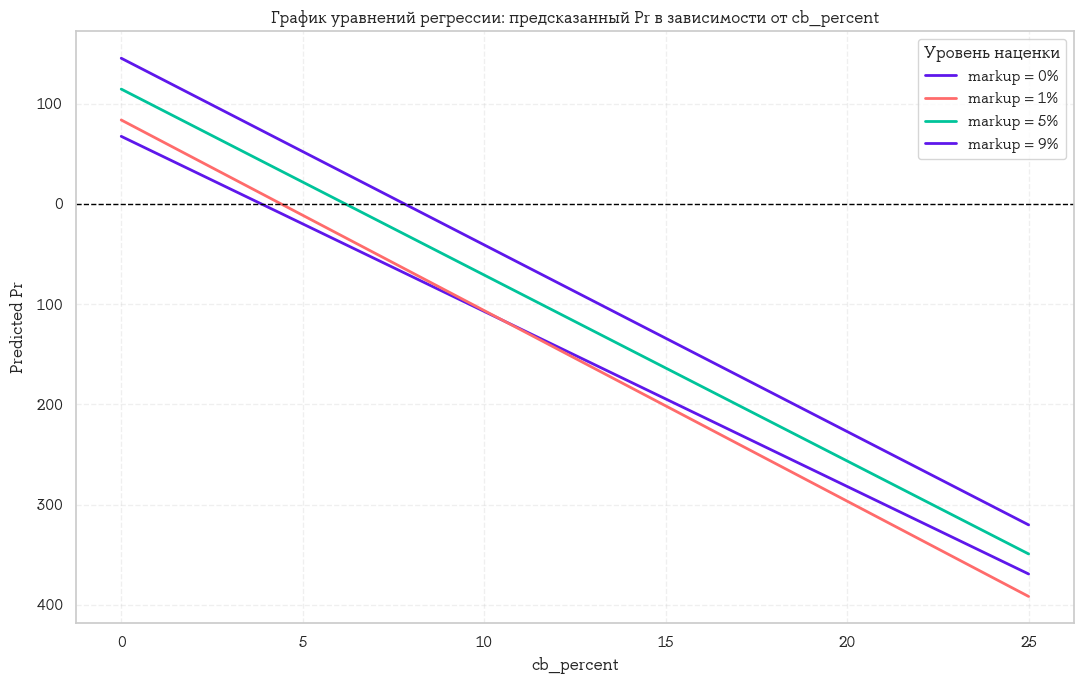

In [9]:
# =========================
# 12. График уравнений модели
# =========================

params = model_pr_cb.params

b0 = params.get('Intercept', 0)
b_cb = params.get('cb_percent', 0)

b_m1 = params.get('markup_1', 0)
b_m5 = params.get('markup_5', 0)
b_m9 = params.get('markup_9', 0)

b_int1 = params.get('cb_x_markup_1', 0)
b_int5 = params.get('cb_x_markup_5', 0)
b_int9 = params.get('cb_x_markup_9', 0)

# Диапазон по оси X
x_min = df_model['cb_percent'].quantile(0.01)
x_max = df_model['cb_percent'].quantile(0.99)
x = np.linspace(x_min, x_max, 200)

# Уравнения прямых для каждой наценки
y_0 = b0 + b_cb * x
y_1 = (b0 + b_m1) + (b_cb + b_int1) * x
y_5 = (b0 + b_m5) + (b_cb + b_int5) * x
y_9 = (b0 + b_m9) + (b_cb + b_int9) * x

plt.figure(figsize=(11, 7))

plt.plot(x, y_0, linewidth=2, label='markup = 0%')
plt.plot(x, y_1, linewidth=2, label='markup = 1%')
plt.plot(x, y_5, linewidth=2, label='markup = 5%')
plt.plot(x, y_9, linewidth=2, label='markup = 9%')

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('График уравнений регрессии: предсказанный Pr в зависимости от cb_percent')
plt.xlabel('cb_percent')
plt.ylabel('Predicted Pr')
plt.legend(title='Уровень наценки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()